In [1]:
import torch
import sys, os
import math as mt

src_dir = os.path.join(os.path.abspath(''), '..')  # goes up from models/ to src/
configs_dir = os.path.join(os.path.abspath(''), '../..')
sys.path.insert(0, os.path.abspath(src_dir))
sys.path.insert(0, os.path.abspath(configs_dir))

In [2]:
from models.autoencoder import Autoencoder
from models.autoencoder import trainSAE, testSAE
from utils.data_loading import QMatrixData

K = 5
lr = 5e-4
train_epochs = 500
in_channels = 4 
num_channels = 10
kernel_dim = 2
maze_dim = 4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(maze_dim**2*in_channels/K)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
import numpy as np
import random
seed = 39
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [4]:
BASE_DIR = os.path.abspath(os.path.join(os.path.abspath(''), '..', '..', '..'))

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)
test_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestest_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstest_4x4.pkl")
)

autoencoder = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

# training language
total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device)

# getting messages from trained language
_, _, _, all_messages, message_dict = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

/Users/nikolaisalazar/Documents/Learning/COS 435/cos435_final_project/.venv/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  

In [6]:
from configs.experiment_config import ExperimentConfig
from rl.teacher import generate_q_matrices
from evaluation.student_eval import train_student, run_evaluations
    
config = ExperimentConfig()
q_matrices, label_dict, wall_state_dict, sopt_dict = generate_q_matrices(config, device)
student = train_student(label_dict, wall_state_dict, sopt_dict, message_dict, config, device)

/Users/nikolaisalazar/Documents/Learning/COS 435/cos435_final_project/.venv/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  

Completed calculation of deterministic Q-matrices
Precomputing analytical task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:00<00:00, 1915.44it/s]


Training analytical student simultaneously on 225 tasks...


Training student (epochs):   7%|▋         | 51/750 [00:06<01:20,  8.65it/s]

...

Epoch 650/750 completed


Training student (epochs):  93%|█████████▎| 701/750 [01:31<00:06,  7.02it/s]

Epoch 700/750 completed


Training student (epochs): 100%|██████████| 750/750 [01:38<00:00,  7.60it/s]

Epoch 750/750 completed


In [7]:
import importlib
import evaluation.student_eval as student_eval
importlib.reload(student_eval)
from evaluation.student_eval import train_student, run_evaluations

informed_rates, misinformed_rates = run_evaluations(student, label_dict, wall_state_dict, message_dict, sopt_dict, config, device)

Informed student:    55.19%
Misinformed student: 39.55%


In [8]:
autoencoder, student = student_eval.train_student_with_feedback(
    label_dict, 
    wall_state_dict, 
    sopt_dict, 
    q_matrices,
    autoencoder, 
    student, 
    config, 
    device,
)

Joint Training (Epochs): 100%|██████████| 750/750 [06:34<00:00,  1.90it/s]


In [9]:
# Extract the optimized messages generated by the newly trained Autoencoder
message_dict_feedback = {}
autoencoder.eval()
with torch.no_grad():
    for task, (wall_label, init_state, goal_state) in label_dict.items():
        q_mat = q_matrices[task].unsqueeze(0).to(device)
        message, _ = autoencoder(q_mat)
        message_dict_feedback[(wall_label, init_state, goal_state)] = message.squeeze(0).detach()

In [10]:
informed_rates, misinformed_rates = student_eval.run_evaluations(
    student, label_dict, wall_state_dict, message_dict_feedback, sopt_dict, config, device
)

Informed student:    91.29%
Misinformed student: 37.93%


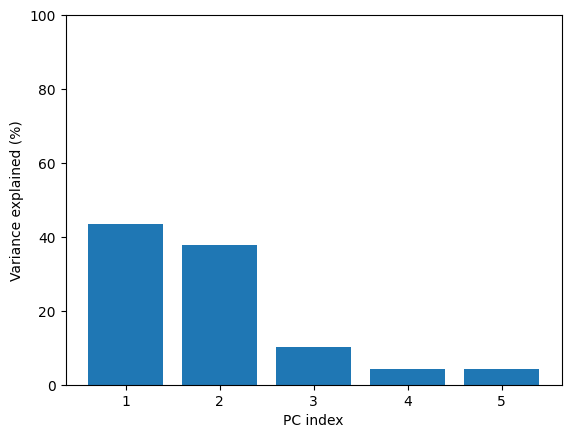

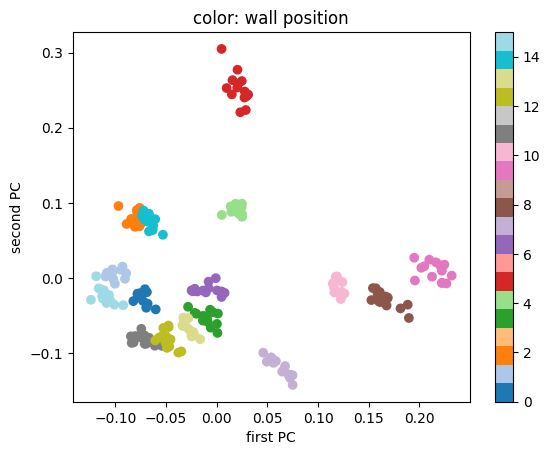

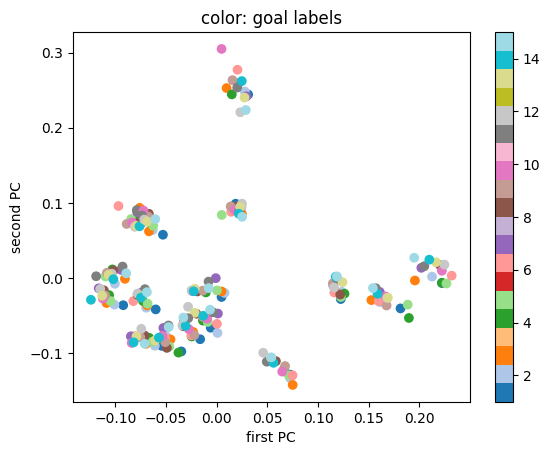

In [28]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")

In [12]:
importlib.reload(student_eval)
from evaluation.student_eval import close_the_loop

student_gen2, student_messages = close_the_loop(
    student, autoencoder, label_dict, wall_state_dict,
    message_dict_feedback, sopt_dict, config, device
)

--- Closing the Loop: extracting student messages ---
--- Closing the Loop: training 2nd-generation student ---
Precomputing analytical task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:00<00:00, 1993.92it/s]


Training analytical student simultaneously on 225 tasks...


Training student (epochs):   7%|▋         | 51/750 [00:04<01:15,  9.28it/s]

Epoch 50/750 completed


...

Epoch 650/750 completed


Training student (epochs):  93%|█████████▎| 701/750 [01:27<00:10,  4.50it/s]

Epoch 700/750 completed


Training student (epochs): 100%|██████████| 750/750 [01:34<00:00,  7.93it/s]

Epoch 750/750 completed


In [16]:
informed_gen2, misinformed_gen2 = student_eval.run_evaluations(
    student_gen2, label_dict, wall_state_dict, student_messages, sopt_dict, config, device
)

Informed student:    86.54%
Misinformed student: 36.61%


In [17]:
# Run additional telephone game iterations starting from gen2
# Each iteration: current student Q-matrices → re-encode → train next student
N_EXTRA = 3  # runs gen3, gen4, gen5

# Seed results table with known values from cells 5, 8, 11
results = {
    'gen':          ['no feedback', 'gen1 (feedback)', 'gen2', 'gen3', 'gen4', 'gen5'],
    'informed':     [55.19, 91.29, 86.54, None, None, None],
    'misinformed':  [39.55, 37.93, 31.97, None, None, None],
}

# Store messages at each generation for PCA analysis
all_messages_by_gen = {
    'gen1 (feedback)': list(message_dict_feedback.values()),
    'gen2': list(student_messages.values()),
}

current_student  = student_gen2
current_messages = student_messages

for i, gen in enumerate(range(3, 3 + N_EXTRA)):
    print(f"\n=== Generation {gen} ===")
    current_student, current_messages = close_the_loop(
        current_student, autoencoder, label_dict, wall_state_dict,
        current_messages, sopt_dict, config, device
    )
    inf, misinf = student_eval.run_evaluations(
        current_student, label_dict, wall_state_dict, current_messages, sopt_dict, config, device
    )
    results['informed'][3 + i]    = round(100 * sum(inf) / len(inf), 2)
    results['misinformed'][3 + i] = round(100 * sum(misinf) / len(misinf), 2)
    all_messages_by_gen[f'gen{gen}'] = list(current_messages.values())


=== Generation 3 ===
--- Closing the Loop: extracting student messages ---
--- Closing the Loop: training 2nd-generation student ---
Precomputing analytical task environments...


Precomputing tasks: 100%|██████████| 225/225 [00:00<00:00, 2484.46it/s]


Training analytical student simultaneously on 225 tasks...


Training student (epochs):   7%|▋         | 52/750 [00:03<00:40, 17.31it/s]

Epoch 50/750 completed


...

Epoch 650/750 completed


Training student (epochs):  94%|█████████▎| 702/750 [00:40<00:02, 17.60it/s]

Epoch 700/750 completed


Training student (epochs): 100%|██████████| 750/750 [00:42<00:00, 17.49it/s]


Epoch 750/750 completed
Informed student:    69.54%
Misinformed student: 34.31%


In [18]:
print(f"{'Condition':<20} {'Informed':>10} {'Misinformed':>13}")
print("-" * 45)
for g, inf, misinf in zip(results['gen'], results['informed'], results['misinformed']):
    print(f"{g:<20} {inf:>9.2f}% {misinf:>12.2f}%")

Condition              Informed   Misinformed
---------------------------------------------
no feedback              55.19%        39.55%
gen1 (feedback)          91.29%        37.93%
gen2                     86.54%        31.97%
gen3                     83.22%        37.59%
gen4                     77.48%        38.63%
gen5                     69.54%        34.31%


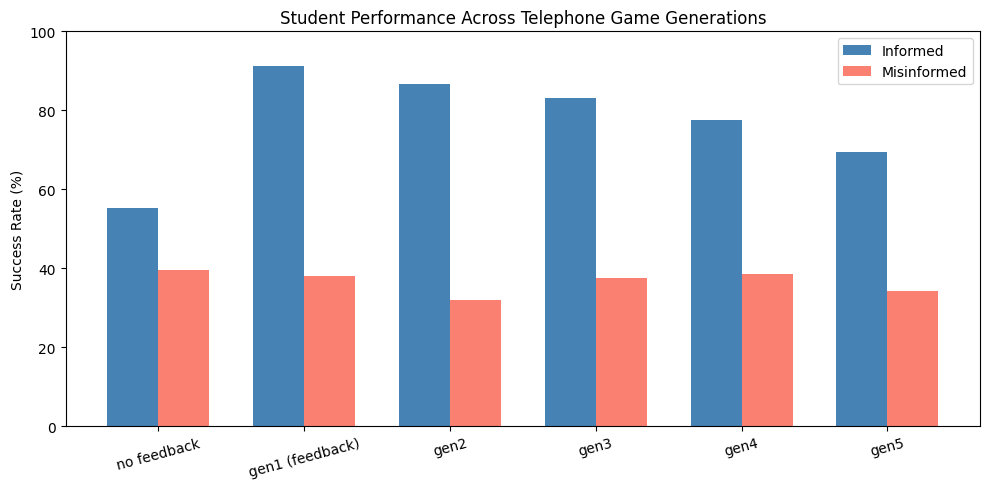

In [29]:
import matplotlib.pyplot as plt
import numpy as np

labels      = results['gen']
informed    = results['informed']
misinformed = results['misinformed']

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, informed,    width, label='Informed',    color='steelblue')
ax.bar(x + width/2, misinformed, width, label='Misinformed', color='salmon')

ax.set_ylabel('Success Rate (%)')
ax.set_title('Student Performance Across Telephone Game Generations')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()

os.makedirs(os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures'), exist_ok=True)
_fig_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures')
plt.savefig(os.path.join(_fig_dir, 'fig_telephone_game.png'), bbox_inches='tight', dpi=150)
plt.show()


--- gen1 (feedback) ---

--- gen2 ---

--- gen3 ---

--- gen4 ---

--- gen5 ---


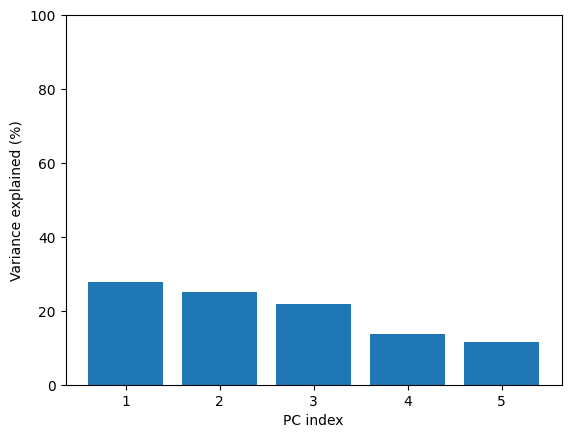

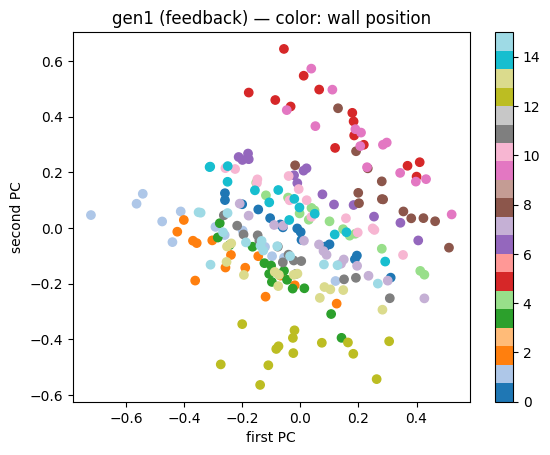

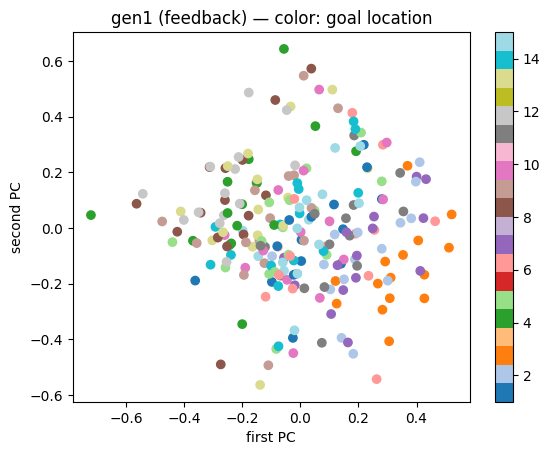

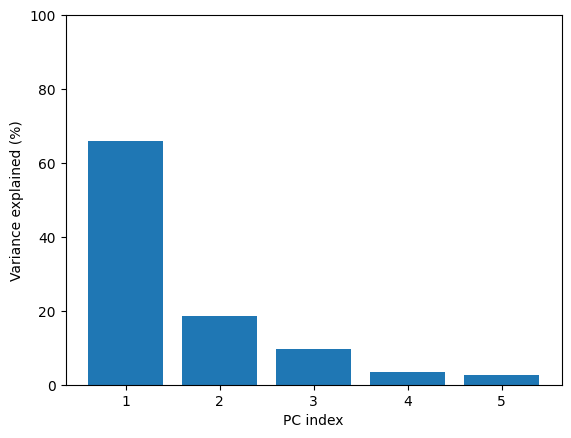

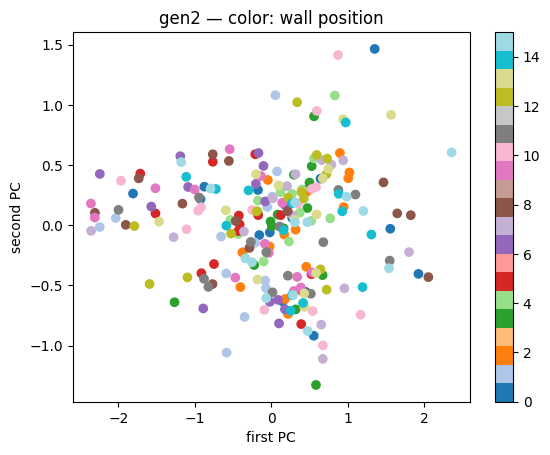

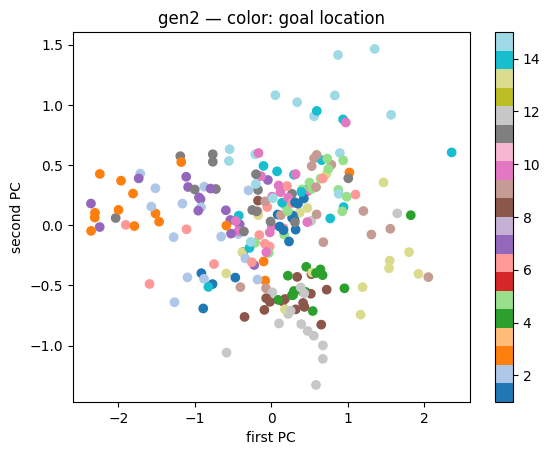

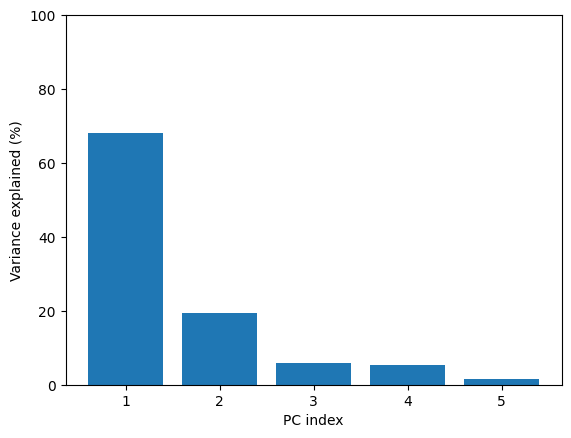

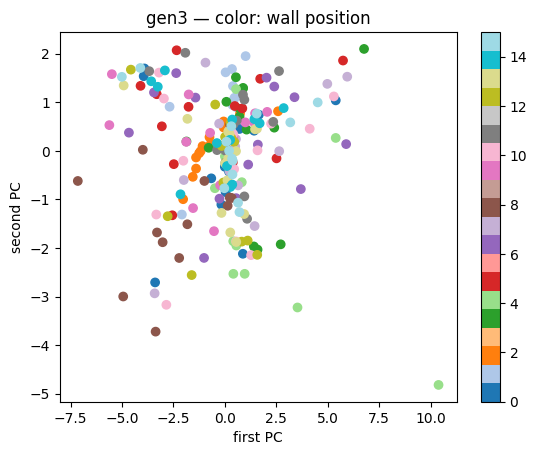

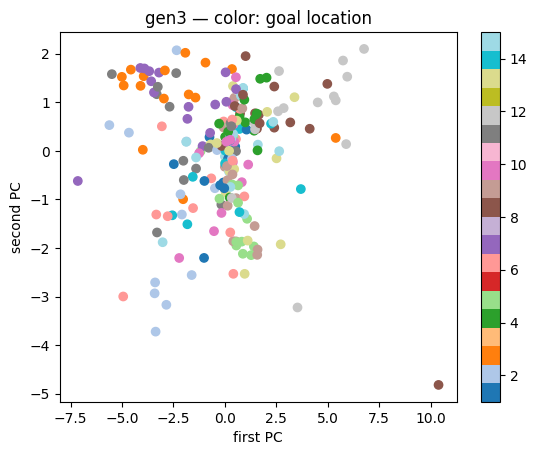

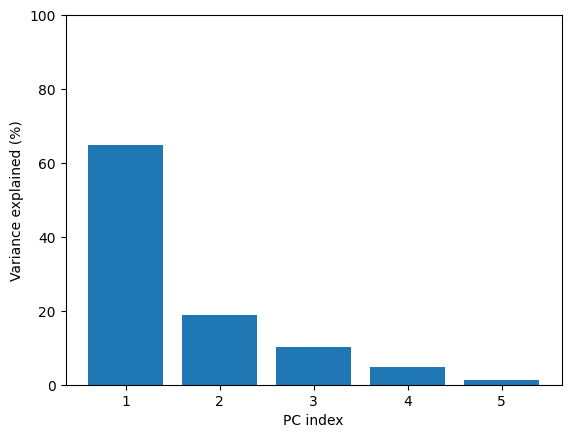

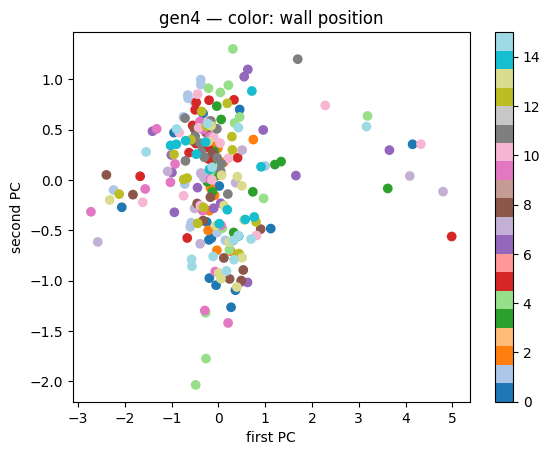

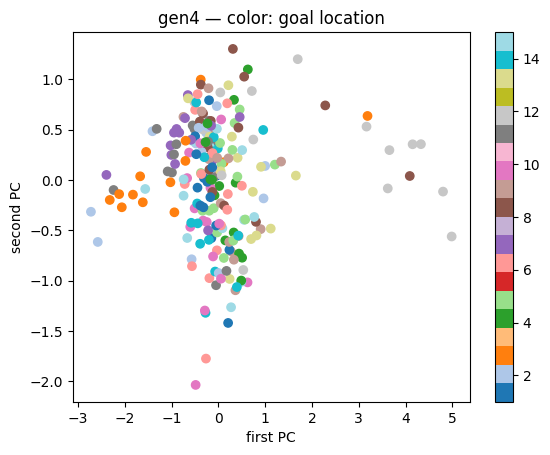

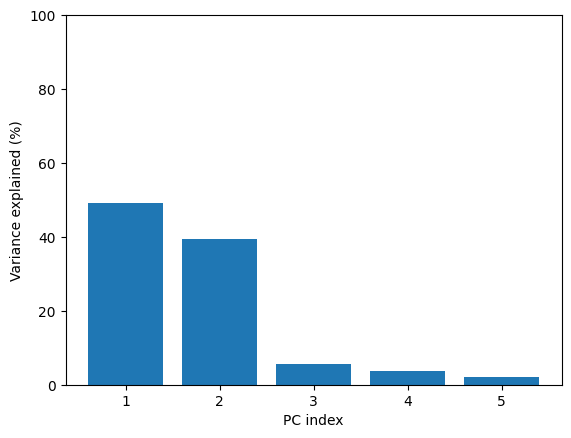

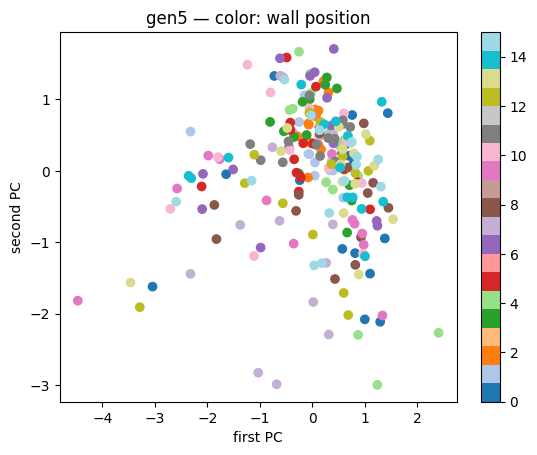

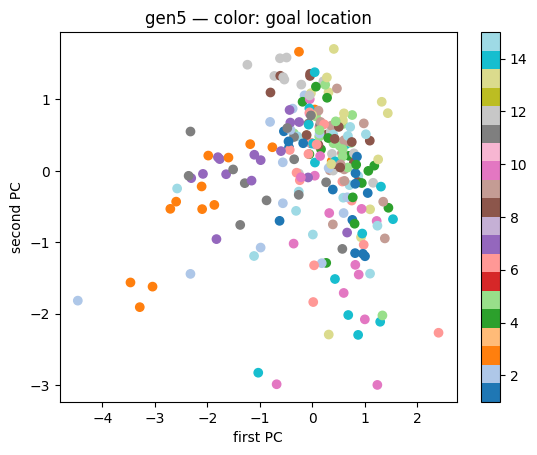

In [30]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

wall_labels = [label_dict[t][0] for t in label_dict]
goal_labels = [label_dict[t][2] for t in label_dict]

for gen_label, msgs in all_messages_by_gen.items():
    msgs_np = torch.stack(msgs).detach().cpu().numpy()
    pca = PCA(n_components=5)
    pca_result = pca.fit_transform(msgs_np)
    print(f"\n--- {gen_label} ---")
    plot_pca_variance(pca)
    plot_pca_by_label(pca_result, wall_labels, f"{gen_label} — color: wall position")
    plot_pca_by_label(pca_result, goal_labels, f"{gen_label} — color: goal location")

In [1]:
# Table 5: Critical F-values for variance analysis
from scipy.stats import f as f_dist
import os

# Degrees of freedom from variance_analyzer structure:
# N = 15 goal groups, M = 210 tasks (14 non-zero walls x 15 goals)
dfn = 14   # N - 1 (between-group)
dfd = 195  # M - N (within-group)

alphas = [0.1, 0.05, 0.01, 0.005, 0.001]

lines = [
    "Table 5 | Critical F-values for goal groupings (dfn=14, dfd=195)",
    "{:<20} {:>8}".format("Significance (a)", "F_crit"),
    "-" * 30,
]
for alpha in alphas:
    f_crit = f_dist.ppf(1 - alpha, dfn, dfd)
    lines.append("{:<20} {:>8.2f}".format(alpha, f_crit))

output = "\n".join(lines)
print(output)

# Save to file
_tbl_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'tables')
os.makedirs(_tbl_dir, exist_ok=True)
with open(os.path.join(_tbl_dir, 'table5_critical_f.txt'), 'w') as _f:
    _f.write(output + "\n")
print("\nSaved to outputs/tables/table5_critical_f.txt")

Table 5 | Critical F-values for goal groupings (dfn=14, dfd=195)
Significance (α)       F_crit
------------------------------
0.1                      1.54
0.05                     1.74
0.01                     2.17
0.005                    2.35
0.001                    2.74


In [ ]:
# Figure 3 (b, c) – Topographic Similarity
# Port of original notebook cell 23-24
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

norm_topo = config.norm_topo    # 2
n_bins    = config.n_bins_topo  # 20
w_goal    = config.goal_reward  # 2.0
w_wall    = config.wall_reward  # -0.5
grid_dim  = config.grid_dim     # 4
n_tasks   = len(label_dict)     # 225

# --- 1. State coordinate lookup (row, col); origin: bottom-left ---
# No-wall (wall_index=0) is placed outside the maze at (grid_dim, grid_dim)
state_coord = {i: np.array([i // grid_dim, i % grid_dim]) for i in range(grid_dim ** 2)}
state_coord[0] = np.array([grid_dim, grid_dim])

# --- 2. Weighted indicator vectors: [w_goal * goal_coord | w_wall * wall_coord] ---
tasks_list = [label_dict[t] for t in range(n_tasks)]
vwdict = {
    t: np.concatenate([w_goal * state_coord[gs], w_wall * state_coord[wi]])
    for t, (wi, _, gs) in enumerate(tasks_list)
}

# --- 3. Flat Q-matrices ---
qdict = {t: q_matrices[t].flatten().detach().numpy() for t in range(n_tasks)}

# --- 4. All lower-triangle pairs and their pairwise distances ---
pairs  = [(i, j) for i in range(n_tasks) for j in range(i + 1, n_tasks)]
qdist  = np.array([np.linalg.norm(qdict[i]  - qdict[j],  ord=norm_topo) for i, j in pairs])
vwdist = np.array([np.linalg.norm(vwdict[i] - vwdict[j], ord=norm_topo) for i, j in pairs])

# Sort pair indices by meaning distance for binning
q_sorted  = sorted(range(len(pairs)), key=lambda k: qdist[k])
vw_sorted = sorted(range(len(pairs)), key=lambda k: vwdist[k])

# --- 5. Convert message dicts from (wall,init,goal) key to task-index key ---
msg_nofb = {t: message_dict[tuple(label_dict[t])].detach().numpy()          for t in range(n_tasks)}
msg_fb   = {t: message_dict_feedback[tuple(label_dict[t])].detach().numpy() for t in range(n_tasks)}

# --- 6. Bin: average message dist per meaning-distance bin ---
def bin_topo(msg_by_task, sorted_keys, meaning_dist, n_bins):
    mdist = np.array([np.linalg.norm(msg_by_task[i] - msg_by_task[j]) for i, j in pairs])
    el = len(sorted_keys) // n_bins
    xvals, yvals = [], []
    for k in range(n_bins):
        chunk = sorted_keys[el * k: el * (k + 1)]
        xvals.append(np.mean(meaning_dist[chunk]))
        yvals.append(np.mean(mdist[chunk]))
    return np.array(xvals), np.array(yvals)

xq_nofb,  yq_nofb  = bin_topo(msg_nofb, q_sorted,  qdist,  n_bins)
xq_fb,    yq_fb    = bin_topo(msg_fb,   q_sorted,  qdist,  n_bins)
xvw_nofb, yvw_nofb = bin_topo(msg_nofb, vw_sorted, vwdist, n_bins)
xvw_fb,   yvw_fb   = bin_topo(msg_fb,   vw_sorted, vwdist, n_bins)

# --- 7. Plot (Figs. 3b, c) ---
def linfunc(x, m, b):
    return m * x + b

cmap_topo = plt.get_cmap("bwr")
fig, ax = plt.subplots(1, 2, figsize=(14, 5.6))

for j, (xnofb, ynofb, xfb, yfb, xlabel) in enumerate([
    (xq_nofb,  yq_nofb,  xq_fb,  yq_fb,  "teacher Q-matrix distance"),
    (xvw_nofb, yvw_nofb, xvw_fb, yvw_fb, "spatial task distance"),
]):
    for x, y, color, label in [
        (xfb,   yfb,   cmap_topo(0.15), "with feedb."),
        (xnofb, ynofb, cmap_topo(0.99), "no feedb."),
    ]:
        popt, pcov = curve_fit(linfunc, x, y)
        m_val = round(popt[0], 3)
        m_std = round(np.sqrt(np.diag(pcov))[0], 3)
        ax[j].scatter(x, y, color=color, s=40, label=f"{label}: m={m_val}\u00b1{m_std}")
        ax[j].plot(x, linfunc(x, *popt), color=color, lw=2)

    ax[j].set_xlabel(xlabel, fontsize=20)
    ax[j].legend(fontsize=14, loc=2)
    ax[j].set_ylim(0, 1.2)
    ax[j].tick_params(width=3, length=8)

ax[0].set_ylabel("message distance", fontsize=20)
ax[0].set_title("teacher meaning", fontsize=22, y=1.05)
ax[1].set_title("spatial meaning",  fontsize=22, y=1.05)
plt.subplots_adjust(wspace=0.5)
plt.show()

In [ ]:
# Figure 3 (d, e) – Shannon Entropy Analysis
# Port of original notebook cells 25-26
import scipy.stats as sp_stats
from sklearn.decomposition import PCA
import torch.nn as nn
from rl.teacher import q_matrix_from_network

H_binlist = config.H_binlist   # e.g. [8, 13, 19, ..., 62]
softy = nn.Softmax(dim=0)

def get_2D_PCA_entropy(input_array, n_bins, method="B"):
    """Project to 2D PCA, histogram, compute Shannon entropy."""
    pca = PCA(n_components=2)
    proj = pca.fit_transform(input_array)
    xv, yv = proj[:, 0], proj[:, 1]
    if method == "A":
        hist, _, _ = np.histogram2d(xv, yv, bins=n_bins)
    else:  # method B: equal-extent square
        delta = max(xv.max() - xv.min(), yv.max() - yv.min()) / 2
        xmid  = (xv.max() + xv.min()) / 2
        ymid  = (yv.max() + yv.min()) / 2
        hist, _, _ = np.histogram2d(xv, yv, bins=n_bins,
                                    range=[[xmid - delta, xmid + delta],
                                           [ymid - delta, ymid + delta]])
    hist = hist.flatten() / hist.sum()
    return sp_stats.entropy(hist)

# --- 1. Teacher Q-matrices (flat numpy) ---
q_teacher_arr = np.array([q_matrices[t].flatten().detach().numpy() for t in range(n_tasks)])

# --- 2. Messages: no-feedback and with-feedback ---
msg_nofb_arr = np.array([message_dict[tuple(label_dict[t])].detach().numpy()          for t in range(n_tasks)])
msg_fb_arr   = np.array([message_dict_feedback[tuple(label_dict[t])].detach().numpy() for t in range(n_tasks)])

# --- 3. Student Q-matrices and probability matrices (feedback student) ---
student.eval()
autoencoder.eval()
q_student_list, p_student_list = [], []
with torch.no_grad():
    for t in range(n_tasks):
        wi, _, gs = label_dict[t]
        msg    = message_dict_feedback[tuple(label_dict[t])].to(device)
        wall_s = wall_state_dict[wi]
        q_mat  = q_matrix_from_network(student, msg, wall_s, config, device).cpu()
        q_student_list.append(q_mat.flatten().numpy())
        p_student_list.append(softy(q_mat.flatten()).numpy())
q_student_arr = np.array(q_student_list)
p_student_arr = np.array(p_student_list)

# --- 4. Entropy across bin sizes (method B = equal extent, as in original) ---
H_q_teacher = np.array([get_2D_PCA_entropy(q_teacher_arr, n) for n in H_binlist])
H_msg_nofb  = np.array([get_2D_PCA_entropy(msg_nofb_arr,  n) for n in H_binlist])
H_msg_fb    = np.array([get_2D_PCA_entropy(msg_fb_arr,    n) for n in H_binlist])
H_p_student = np.array([get_2D_PCA_entropy(p_student_arr, n) for n in H_binlist])

# --- 5. Plot (Fig. 3e) ---
Hmax = sp_stats.entropy([1 / n_tasks] * n_tasks)  # log(225) ≈ 5.42
cmap_ent = plt.get_cmap("bwr")

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot([H_binlist[0], H_binlist[-1]], [Hmax, Hmax],
        ls="--", color="black", label="maximum possible entropy", lw=2)

entries = [
    (H_q_teacher, "black",         "o", "teacher Q-matrices"),
    (H_msg_fb,    cmap_ent(0.12),  "D", "messages w/ feedback"),
    (H_msg_nofb,  cmap_ent(0.99),  "s", "messages w/o feedback"),
    (H_p_student, cmap_ent(0.35),  "D", "student action prob. matrices"),
]
for H, color, marker, label in entries:
    ax.scatter(H_binlist, H, color=color, marker=marker, s=75, label=label, lw=2)

ax.set_xlabel(r"bins per PC-axis ($\it{n}$)", fontsize=22)
ax.set_ylabel("Shannon entropy", fontsize=22)
ax.set_title("entropy at different comm. stages", fontsize=22)
ax.set_xlim(0, 64)
ax.set_ylim(2, 5.5)
ax.legend(fontsize=12, loc=4)
ax.tick_params(width=3, length=8)
fig.tight_layout()
plt.show()

In [26]:
# Figure 4: Training loop — 7 groups × 5 languages = 35 runs
# Each run jointly trains a fresh autoencoder+student on a goal-location subset
import scipy.stats as sp_stats
import importlib
import evaluation.student_eval as student_eval
importlib.reload(student_eval)

N_LANGS  = 5
N_GROUPS = 7

def make_message_dict(ae, ld, qmats, device):
    """Generate {(wall,init,goal): message} for all tasks in ld."""
    ae.eval()
    mdict = {}
    with torch.no_grad():
        for task_idx, label in ld.items():
            wi, init, goal = label[0], label[1], label[2]
            q = qmats[task_idx].unsqueeze(0).to(device)
            msg, _ = ae(q)
            mdict[(wi, init, goal)] = msg.squeeze(0).detach()
    return mdict

# fig4_rates[g][cond][student]: list of per-language mean solving rates
# cond 0: trained goals,  trained mazes
# cond 1: unknown goals,  trained mazes
# cond 2: trained goals,  unknown mazes
# cond 3: unknown goals,  unknown mazes
# student 0 = informed, 1 = misinformed
fig4_rates = {
    g: {cond: {s: [] for s in range(2)} for cond in range(4)}
    for g in range(N_GROUPS)
}

for g in range(N_GROUPS):
    train_goals   = train_goals_dict[g]
    unknown_goals = [gs for gs in range(1, 16) if gs not in train_goals]

    print(f"\n{'='*55}")
    print(f"Goal group {g}: train on {train_goals}")
    print(f"{'='*55}")

    # Filter training tasks to selected goal locations
    filt_label = {t: lbl for t, lbl in label_dict.items()  if lbl[2] in train_goals}
    filt_qmat  = {t: q_matrices[t]  for t in filt_label}
    filt_sopt  = {t: sopt_dict[t]   for t in filt_label}

    for l in range(N_LANGS):
        print(f"\n--- Group {g}, Language {l+1}/{N_LANGS} ---")

        # Fresh models for each run
        ae_run  = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
        std_run = DQN(K=config.K, n_actions=config.n_actions, device=device)

        # Joint training with student feedback on filtered tasks
        ae_run, std_run = student_eval.train_student_with_feedback(
            filt_label, wall_state_dict, filt_sopt, filt_qmat,
            ae_run, std_run, config, device
        )

        # Generate messages for both train and unknown-maze tasks
        msg_train = make_message_dict(ae_run, label_dict,       q_matrices,       device)
        msg_test  = make_message_dict(ae_run, label_dict_unk_maze, q_matrices_unk_maze, device)

        # 4 filtered label dicts
        ld_conds = [
            ({t: lbl for t, lbl in label_dict.items()        if lbl[2] in train_goals},   wall_state_dict,      msg_train, sopt_dict),
            ({t: lbl for t, lbl in label_dict.items()        if lbl[2] in unknown_goals}, wall_state_dict,      msg_train, sopt_dict),
            ({t: lbl for t, lbl in label_dict_unk_maze.items() if lbl[2] in train_goals},   wall_state_dict_test, msg_test,  sopt_dict_unk_maze),
            ({t: lbl for t, lbl in label_dict_unk_maze.items() if lbl[2] in unknown_goals}, wall_state_dict_test, msg_test,  sopt_dict_unk_maze),
        ]

        for cond_idx, (ld_c, wsd, msg, so) in enumerate(ld_conds):
            if len(ld_c) == 0:
                continue  # group 0 has no unknown goals
            inf, misinf = student_eval.run_evaluations(std_run, ld_c, wsd, msg, so, config, device)
            fig4_rates[g][cond_idx][0].append(sum(inf)   / len(inf))
            fig4_rates[g][cond_idx][1].append(sum(misinf)/ len(misinf))
            print(f"  cond {cond_idx}: inf={fig4_rates[g][cond_idx][0][-1]:.3f}  misinf={fig4_rates[g][cond_idx][1][-1]:.3f}")

print("\nAll 35 runs complete!")


Goal group 0: train on [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]

--- Group 0, Language 1/5 ---


Joint Training (Epochs): 100%|██████████| 750/750 [03:42<00:00,  3.37it/s]


Informed student:    95.78%
Misinformed student: 36.23%
  cond 0: inf=0.958  misinf=0.362
Informed student:    85.63%
Misinformed student: 34.02%
  cond 2: inf=0.856  misinf=0.340

--- Group 0, Language 2/5 ---


Joint Training (Epochs): 100%|██████████| 750/750 [04:18<00:00,  2.90it/s]


Informed student:    51.33%
Misinformed student: 29.29%
  cond 0: inf=0.513  misinf=0.293
Informed student:    46.91%
Misinformed student: 27.16%
  cond 2: inf=0.469  misinf=0.272

--- Group 0, Language 3/5 ---


...

Informed student:    92.50%
Misinformed student: 44.97%
  cond 0: inf=0.925  misinf=0.450
Informed student:    19.74%
Misinformed student: 22.15%
  cond 1: inf=0.197  misinf=0.222
Informed student:    80.70%
Misinformed student: 39.60%
  cond 2: inf=0.807  misinf=0.396
Informed student:    21.93%
Misinformed student: 20.51%
  cond 3: inf=0.219  misinf=0.205

--- Group 6, Language 4/5 ---


Joint Training (Epochs): 100%|██████████| 750/750 [01:49<00:00,  6.83it/s]


Informed student:    96.75%
Misinformed student: 53.60%
  cond 0: inf=0.968  misinf=0.536
Informed student:    23.89%
Misinformed student: 26.36%
  cond 1: inf=0.239  misinf=0.264
Informed student:    84.81%
Misinformed student: 34.62%
  cond 2: inf=0.848  misinf=0.346
Informed student:    29.94%
Misinformed student: 24.89%
  cond 3: inf=0.299  misinf=0.249

--- Group 6, Language 5/5 ---


Joint Training (Epochs): 100%|██████████| 750/750 [01:50<00:00,  6.78it/s]


Informed student:    97.42%
Misinformed student: 50.29%
  cond 0: inf=0.974  misinf=0.503
Informed student:    25.27%
Misinformed student: 24.36%
  cond 1: inf=0.253  misinf=0.244
Informed student:    84.51%
Misinformed student: 36.62%
  cond 2: inf=0.845  misinf=0.366
Informed student:    26.35%
Misinformed student: 25.30%
  cond 3: inf=0.263  misinf=0.253

All 35 runs complete!


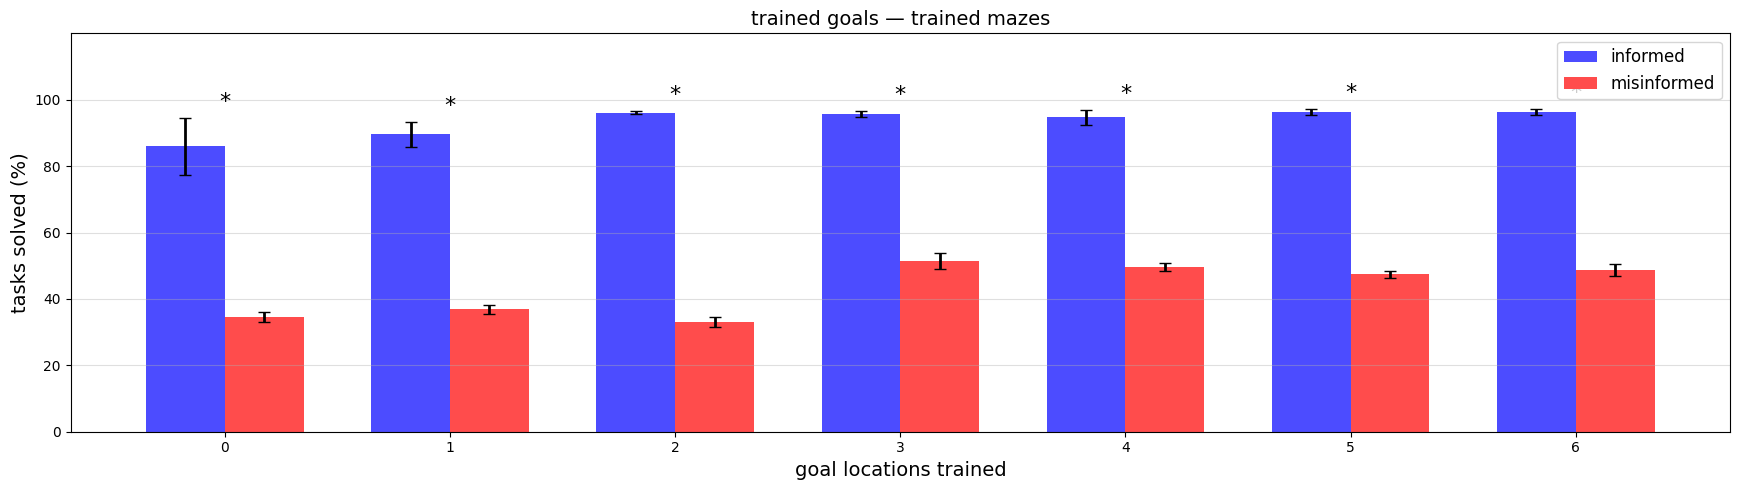

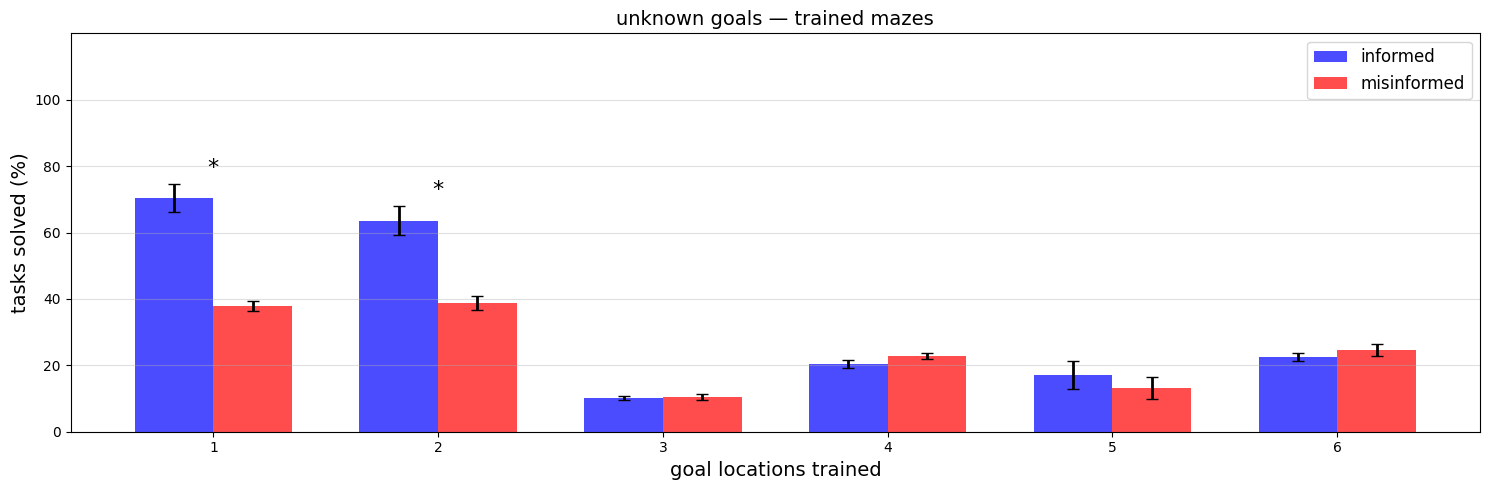

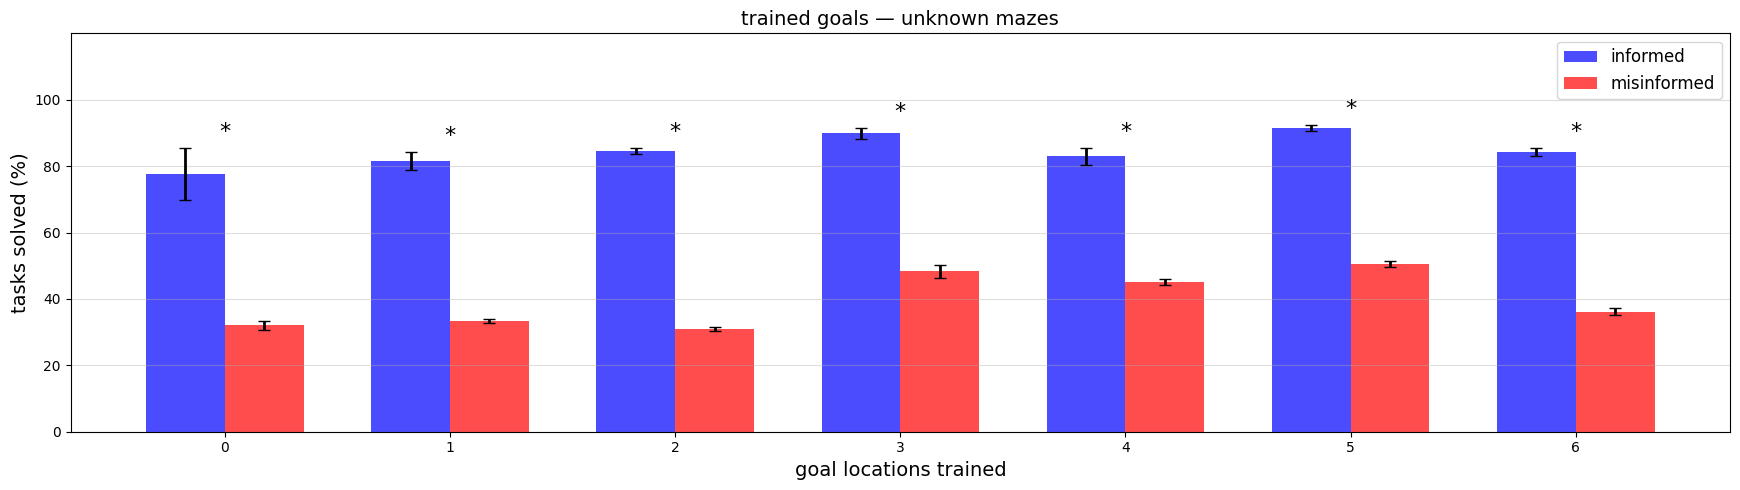

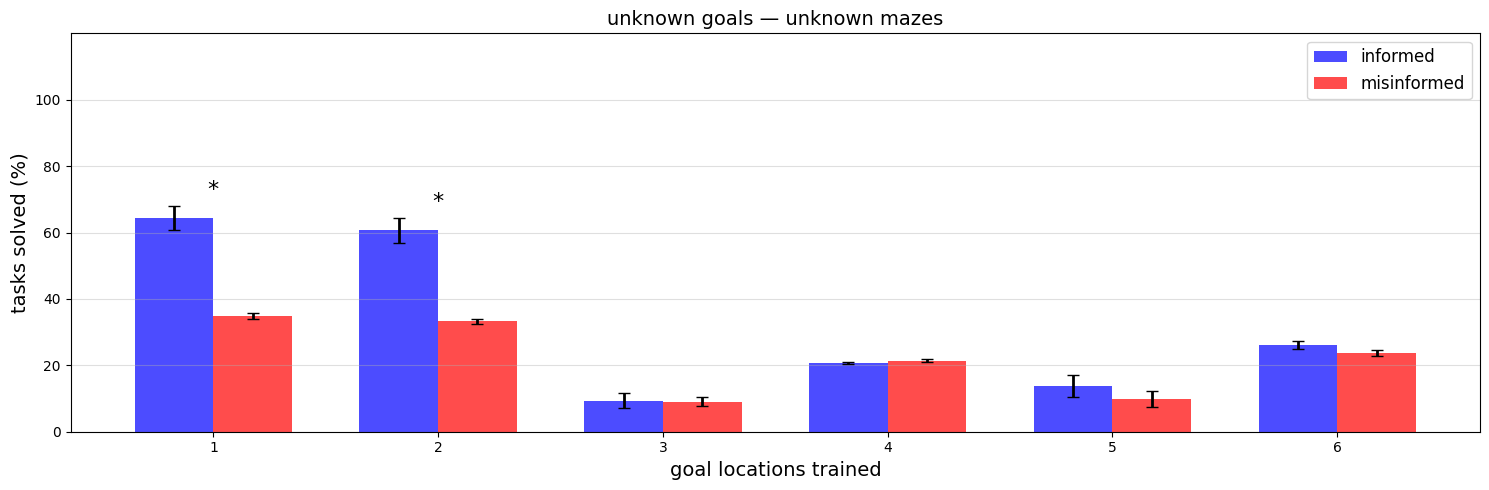

In [31]:
# Figure 4 Plots: 4 bar charts (one per evaluation condition)
import scipy.stats as sp_stats

cmap_fig4 = plt.get_cmap("bwr")
cond_titles = [
    "trained goals — trained mazes",
    "unknown goals — trained mazes",
    "trained goals — unknown mazes",
    "unknown goals — unknown mazes",
]

for cond_idx in range(4):
    # groups included: all 7 for conds 0,2; exclude group 0 (all goals) for conds 1,3
    groups = list(range(N_GROUPS)) if cond_idx in [0, 2] else list(range(1, N_GROUPS))
    
    avg_inf,   sem_inf   = [], []
    avg_misinf, sem_misinf = [], []
    pvals = []

    for g in groups:
        inf_rates   = fig4_rates[g][cond_idx][0]
        misinf_rates = fig4_rates[g][cond_idx][1]
        if len(inf_rates) == 0:
            continue
        n = len(inf_rates)
        avg_inf.append(100 * np.mean(inf_rates))
        sem_inf.append(100 * np.std(inf_rates, ddof=1) / np.sqrt(n) if n > 1 else 0)
        avg_misinf.append(100 * np.mean(misinf_rates))
        sem_misinf.append(100 * np.std(misinf_rates, ddof=1) / np.sqrt(n) if n > 1 else 0)
        if n > 1:
            pvals.append(sp_stats.ttest_ind(inf_rates, misinf_rates).pvalue)
        else:
            pvals.append(1.0)

    x     = np.arange(len(groups))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(8, 2.5*len(groups)), 5))

    bars_inf   = ax.bar(x - width/2, avg_inf,   width, color=cmap_fig4(0.15), label="informed")
    bars_misinf = ax.bar(x + width/2, avg_misinf, width, color=cmap_fig4(0.85), label="misinformed")

    ax.errorbar(x - width/2, avg_inf,   yerr=sem_inf,   fmt="none", ecolor="black", capsize=4, elinewidth=2)
    ax.errorbar(x + width/2, avg_misinf, yerr=sem_misinf, fmt="none", ecolor="black", capsize=4, elinewidth=2)

    # significance markers
    for i, (yi, ym, p) in enumerate(zip(avg_inf, avg_misinf, pvals)):
        if p < 0.05 and yi > ym:
            y_star = max(yi + sem_inf[i], ym + sem_misinf[i]) + 3
            ax.annotate("*", xy=(x[i], y_star), ha="center", fontsize=16)

    ax.set_ylim(0, 120)
    ax.set_yticks([0, 20, 40, 60, 80, 100])
    ax.set_ylabel("tasks solved (%)", fontsize=14)
    ax.set_xlabel("goal locations trained", fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels([str(g) for g in groups])
    ax.set_title(cond_titles[cond_idx], fontsize=14)
    ax.legend(fontsize=12)
    ax.grid(axis="y", alpha=0.4)
    plt.tight_layout()
    os.makedirs(os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures'), exist_ok=True)
    _fig_dir = os.path.join(os.path.abspath(''), '..', '..', '..', 'outputs', 'figures')
    plt.savefig(os.path.join(_fig_dir, f'fig4_cond{cond_idx}.png'), bbox_inches='tight', dpi=150)
    plt.show()